<a href="https://colab.research.google.com/github/Sonalii06/stock-price-movement-predictor/blob/main/Stock_Price_Movement_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Stock Price Movement Predictor

### Time-Series Machine Learning Project

**Tech Stack:** Python, pandas, scikit-learn, matplotlib

## Goal

To predict the next-day stock price direction (**Up** or **Down**) using historical daily OHLCV data and technical indicators.

This project focuses on:

- Leak-free target construction
- Time-series feature engineering
- Proper naive baselines
- Chronological train-test splitting
- Comparing raw and engineered features
- Comparing two machine learning models on the final feature set
- Honest evaluation of market prediction performance

## 1. Reproducibility and Dependencies

This project uses fixed random seeds where applicable and records
the Python package versions used during execution.

This helps make the experiment reproducible.

In [2]:
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import matplotlib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import TimeSeriesSplit

import yfinance as yf


# Reproducibility configuration
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Random seed:", SEED)
print("Imports loaded successfully!")

Random seed: 42
Imports loaded successfully!


In [3]:
print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("yfinance:", yf.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
pandas: 2.2.3
numpy: 2.1.3
scikit-learn: 1.6.1
matplotlib: 3.10.0
yfinance: 0.2.66


## 2. Data Collection

Historical daily OHLCV data is downloaded for Apple Inc. (AAPL).

The dataset contains:

- Open
- High
- Low
- Close
- Volume

AAPL is used because it is a highly liquid stock with sufficient
historical trading data for time-series analysis.

In [4]:
ticker = "AAPL"

data = yf.download(
    ticker,
    start="2018-01-01",
    end="2026-01-01",
    interval="1d",
    auto_adjust=True
)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.232372,40.241717,39.531704,39.741907,102223600
2018-01-03,40.225376,40.767228,40.162319,40.295444,118071600
2018-01-04,40.412205,40.514970,40.190327,40.297761,89738400
2018-01-05,40.872330,40.958744,40.416896,40.507983,94640000
2018-01-08,40.720509,41.014788,40.622412,40.720509,82271200


In [5]:
# Flatten yfinance MultiIndex columns
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print("Columns:")
print(data.columns.tolist())

data.head()

Columns:
['Close', 'High', 'Low', 'Open', 'Volume']


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.232372,40.241717,39.531704,39.741907,102223600
2018-01-03,40.225376,40.767228,40.162319,40.295444,118071600
2018-01-04,40.412205,40.514970,40.190327,40.297761,89738400
2018-01-05,40.872330,40.958744,40.416896,40.507983,94640000
2018-01-08,40.720509,41.014788,40.622412,40.720509,82271200


## 3. Initial Data Inspection

Before creating the prediction target, we inspect the dataset for:

- Number of observations
- Date range
- Missing values
- Data types
- Basic structure

In [6]:
print("Dataset shape:", data.shape)

print("\nDate range:")
print("Start:", data.index.min())
print("End:", data.index.max())

print("\nMissing values:")
print(data.isnull().sum())

print("\nData types:")
print(data.dtypes)

print("\nFirst 5 rows:")
display(data.head())

print("\nLast 5 rows:")
display(data.tail())

Dataset shape: (2011, 5)

Date range:
Start: 2018-01-02 00:00:00
End: 2025-12-31 00:00:00

Missing values:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Data types:
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

First 5 rows:


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.232372,40.241717,39.531704,39.741907,102223600
2018-01-03,40.225376,40.767228,40.162319,40.295444,118071600
2018-01-04,40.412205,40.514970,40.190327,40.297761,89738400
2018-01-05,40.872330,40.958744,40.416896,40.507983,94640000
2018-01-08,40.720509,41.014788,40.622412,40.720509,82271200



Last 5 rows:


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-12-24,273.066742,274.682340,271.461127,271.600731,17910600
2025-12-26,272.657806,274.622460,272.119264,273.415753,21521800
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200
2025-12-30,272.338684,273.335969,271.540868,272.069428,22139600
2025-12-31,271.122009,272.937076,271.012322,272.318764,27293600


## 4. Leak-Free Target Construction

The target represents the direction of the next trading day's closing price.

- `Target = 1` → next day's Close is higher than today's Close
- `Target = 0` → next day's Close is not higher than today's Close

The next-day price is created using `shift(-1)` only to construct the label.

It will NOT be used as a model feature.

In [7]:
# Create the next day's closing price
data["Next_Close"] = data["Close"].shift(-1)

# Create the prediction target
data["Target"] = (
    data["Next_Close"] > data["Close"]
).astype(int)

print("Label shift used: Close.shift(-1)")

Label shift used: Close.shift(-1)


In [8]:
# Explicitly verify target construction
verification_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Next_Close",
    "Target"
]

display(data[verification_columns].head(10))

print("Next_Close is used only for target construction.")
print("Next_Close will NOT be included in the model features.")

Price,Open,High,Low,Close,Volume,Next_Close,Target
Date,,,,,,,
2018-01-02,39.741907,40.241717,39.531704,40.232372,102223600,40.225376,0
2018-01-03,40.295444,40.767228,40.162319,40.225376,118071600,40.412205,1
2018-01-04,40.297761,40.514970,40.190327,40.412205,89738400,40.872330,1
2018-01-05,40.507983,40.958744,40.416896,40.872330,94640000,40.720509,0
2018-01-08,40.720509,41.014788,40.622412,40.720509,82271200,40.715839,0
2018-01-09,40.767222,40.886334,40.500968,40.715839,86336000,40.706497,0
2018-01-10,40.442581,40.708835,40.405211,40.706497,95839600,40.937710,1
2018-01-11,40.776556,40.986758,40.753202,40.937710,74670800,41.360443,1
2018-01-12,41.147906,41.423504,41.024122,41.360443,101672400,41.150253,0


Next_Close is used only for target construction.
Next_Close will NOT be included in the model features.


In [9]:
# Remove the final row because it has no next-day price
data = data.dropna(subset=["Next_Close"]).copy()

# Next_Close is no longer needed
data = data.drop(columns=["Next_Close"])

print("Dataset shape after target construction:", data.shape)
display(data.tail())

Dataset shape after target construction: (2010, 6)


Price,Close,High,Low,Open,Volume,Target
Date,,,,,,
2025-12-23,271.620667,271.760301,268.828279,270.104803,29642000,1
2025-12-24,273.066742,274.682340,271.461127,271.600731,17910600,0
2025-12-26,272.657806,274.622460,272.119264,273.415753,21521800,1
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200,0
2025-12-30,272.338684,273.335969,271.540868,272.069428,22139600,0


## 5. Feature Engineering

Technical indicators are calculated using only current and past information.

The engineered features are:

- **SMA_10** — 10-day moving average
- **Momentum_5** — 5-day price momentum
- **Return_1** — one-day percentage return
- **Volatility_10** — 10-day rolling volatility
- **Volume_Change** — daily percentage change in trading volume

No future information is used in these features.

In [10]:
# 10-day Simple Moving Average
data["SMA_10"] = data["Close"].rolling(window=10).mean()

# 5-day price momentum
data["Momentum_5"] = data["Close"] - data["Close"].shift(5)

# 1-day percentage return
data["Return_1"] = data["Close"].pct_change()

# 10-day rolling volatility
data["Volatility_10"] = data["Return_1"].rolling(window=10).std()

# Daily volume percentage change
data["Volume_Change"] = data["Volume"].pct_change()

display(data.head(15))

Price,Close,High,Low,Open,Volume,Target,SMA_10,Momentum_5,Return_1,Volatility_10,Volume_Change
Date,,,,,,,,,,,
2018-01-02,40.232372,40.241717,39.531704,39.741907,102223600,0,NaN,NaN,NaN,NaN,NaN
2018-01-03,40.225376,40.767228,40.162319,40.295444,118071600,1,NaN,NaN,-0.000174,NaN,0.155033
2018-01-04,40.412205,40.514970,40.190327,40.297761,89738400,1,NaN,NaN,0.004645,NaN,-0.239966
2018-01-05,40.872330,40.958744,40.416896,40.507983,94640000,0,NaN,NaN,0.011386,NaN,0.054621
2018-01-08,40.720509,41.014788,40.622412,40.720509,82271200,0,NaN,NaN,-0.003715,NaN,-0.130693
2018-01-09,40.715839,40.886334,40.500968,40.767222,86336000,0,NaN,0.483467,-0.000115,NaN,0.049407
2018-01-10,40.706497,40.708835,40.405211,40.442581,95839600,1,NaN,0.481121,-0.000229,NaN,0.110077
2018-01-11,40.937710,40.986758,40.753202,40.776556,74670800,1,NaN,0.525505,0.005680,NaN,-0.220877
2018-01-12,41.360443,41.423504,41.024122,41.147906,101672400,0,NaN,0.488113,0.010326,NaN,0.361609


## 6. Remove Rows with Missing Feature Values

Rolling indicators and percentage changes create missing values at the beginning
of the dataset. These rows cannot be used for modeling, so they are removed.

In [11]:
data = data.dropna().copy()

print("Final modeling dataset shape:", data.shape)
print("Missing values:")
print(data.isnull().sum())

Final modeling dataset shape: (2000, 11)
Missing values:
Price
Close            0
High             0
Low              0
Open             0
Volume           0
Target           0
SMA_10           0
Momentum_5       0
Return_1         0
Volatility_10    0
Volume_Change    0
dtype: int64


## 7. Class Balance

Before training the models, we check how many observations belong to each
direction class.

- 0 = Down
- 1 = Up

This helps determine whether the dataset is reasonably balanced and provides
context for interpreting model accuracy.

In [12]:
class_counts = data["Target"].value_counts().sort_index()
class_percentages = data["Target"].value_counts(normalize=True).sort_index() * 100

class_balance = pd.DataFrame({
    "Class": ["Down (0)", "Up (1)"],
    "Count": [
        class_counts.get(0, 0),
        class_counts.get(1, 0)
    ],
    "Percentage": [
        class_percentages.get(0, 0),
        class_percentages.get(1, 0)
    ]
})

display(class_balance)

print("Total observations:", len(data))

,Class,Count,Percentage
0,Down (0),928,46.4
1,Up (1),1072,53.6


Total observations: 2000


## 8. Time-Based Train-Test Split

Because this is time-series data, the dataset is split chronologically.

- First 80% → training data
- Last 20% → unseen test data

Random shuffling is avoided because it could allow future information
to influence the training process.

In [13]:
split_index = int(len(data) * 0.80)

train_data = data.iloc[:split_index].copy()
test_data = data.iloc[split_index:].copy()

print("Training period:", train_data.index.min(), "to", train_data.index.max())
print("Test period:", test_data.index.min(), "to", test_data.index.max())

print("\nTraining samples:", len(train_data))
print("Test samples:", len(test_data))

Training period: 2018-01-17 00:00:00 to 2024-05-24 00:00:00
Test period: 2024-05-28 00:00:00 to 2025-12-30 00:00:00

Training samples: 1600
Test samples: 400


## 9. Naive Baselines

Two simple baselines are used before evaluating machine learning models.

### Persistence Baseline
Predict that tomorrow's direction will be the same as today's direction.

### Majority Class Baseline
Always predict the most common class observed in the training data.

These baselines provide a minimum performance level that the ML models
should be compared against.

In [16]:
# Create today's direction using today's and previous day's Close
data["Today_Direction"] = (
    data["Close"] > data["Close"].shift(1)
).astype(int)

# Get the corresponding values for the test period
test_data["Today_Direction"] = data.loc[
    test_data.index, "Today_Direction"
]

# -------------------------
# Persistence Baseline
# -------------------------
persistence_predictions = test_data["Today_Direction"]

persistence_accuracy = accuracy_score(
    test_data["Target"],
    persistence_predictions
)

# -------------------------
# Majority Class Baseline
# -------------------------
# IMPORTANT: majority class is calculated from training data only
majority_class = train_data["Target"].mode()[0]

majority_predictions = np.full(
    len(test_data),
    majority_class
)

majority_accuracy = accuracy_score(
    test_data["Target"],
    majority_predictions
)

print(f"Persistence Baseline Accuracy: {persistence_accuracy:.2%}")
print(f"Majority Class Baseline Accuracy: {majority_accuracy:.2%}")
print(f"Majority class from training data: {majority_class}")

Persistence Baseline Accuracy: 52.25%
Majority Class Baseline Accuracy: 56.25%
Majority class from training data: 1


## 10. Raw-Feature Logistic Regression

The first machine learning model uses only the original OHLCV features:

- Open
- High
- Low
- Close
- Volume

No technical indicators are used.

A StandardScaler is fitted **only on the training data** to prevent
information from the test period from influencing preprocessing.

In [17]:
raw_features = ["Open", "High", "Low", "Close", "Volume"]

X_train_raw = train_data[raw_features]
X_test_raw = test_data[raw_features]

y_train = train_data["Target"]
y_test = test_data["Target"]

# Fit scaler ONLY on training data
raw_scaler = StandardScaler()

X_train_raw_scaled = raw_scaler.fit_transform(X_train_raw)
X_test_raw_scaled = raw_scaler.transform(X_test_raw)

# Train Logistic Regression
raw_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

raw_model.fit(X_train_raw_scaled, y_train)

raw_predictions = raw_model.predict(X_test_raw_scaled)

raw_accuracy = accuracy_score(
    y_test,
    raw_predictions
)

print(f"Raw OHLCV Logistic Regression Accuracy: {raw_accuracy:.2%}")

Raw OHLCV Logistic Regression Accuracy: 45.00%


## 11. Engineered-Feature Models

The final feature set uses the technical indicators created earlier:

- SMA_10
- Momentum_5
- Return_1
- Volatility_10
- Volume_Change

Two different models will be trained on this **same final feature set**:

1. Logistic Regression
2. Random Forest

This allows us to compare both feature engineering and model choice.

In [18]:
engineered_features = [
    "SMA_10",
    "Momentum_5",
    "Return_1",
    "Volatility_10",
    "Volume_Change"
]

X_train_eng = train_data[engineered_features]
X_test_eng = test_data[engineered_features]

# Scale for Logistic Regression
eng_scaler = StandardScaler()

X_train_eng_scaled = eng_scaler.fit_transform(X_train_eng)
X_test_eng_scaled = eng_scaler.transform(X_test_eng)

# Engineered Logistic Regression
eng_lr_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

eng_lr_model.fit(X_train_eng_scaled, y_train)

eng_lr_predictions = eng_lr_model.predict(X_test_eng_scaled)

eng_lr_accuracy = accuracy_score(
    y_test,
    eng_lr_predictions
)

print(f"Engineered Logistic Regression Accuracy: {eng_lr_accuracy:.2%}")

Engineered Logistic Regression Accuracy: 47.75%


In [19]:
# Random Forest does not require feature scaling
eng_rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1
)

eng_rf_model.fit(X_train_eng, y_train)

eng_rf_predictions = eng_rf_model.predict(X_test_eng)

eng_rf_accuracy = accuracy_score(
    y_test,
    eng_rf_predictions
)

print(f"Engineered Random Forest Accuracy: {eng_rf_accuracy:.2%}")

Engineered Random Forest Accuracy: 46.75%


## 12. Forward Time-Series Cross-Validation

To evaluate model stability without shuffling time-series data, we use
`TimeSeriesSplit`.

Each fold trains on earlier observations and validates on later observations.

The scaler for Logistic Regression is fitted separately inside each fold,
using only that fold's training data.

In [20]:
tscv = TimeSeriesSplit(n_splits=5)

lr_cv_scores = []
rf_cv_scores = []

X_cv = train_data[engineered_features]
y_cv = train_data["Target"]

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_cv), start=1):

    X_fold_train = X_cv.iloc[train_idx]
    X_fold_val = X_cv.iloc[val_idx]

    y_fold_train = y_cv.iloc[train_idx]
    y_fold_val = y_cv.iloc[val_idx]

    # Logistic Regression
    fold_scaler = StandardScaler()

    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train)
    X_fold_val_scaled = fold_scaler.transform(X_fold_val)

    fold_lr = LogisticRegression(
        max_iter=1000,
        random_state=SEED
    )

    fold_lr.fit(X_fold_train_scaled, y_fold_train)

    lr_pred = fold_lr.predict(X_fold_val_scaled)

    lr_score = accuracy_score(y_fold_val, lr_pred)
    lr_cv_scores.append(lr_score)

    # Random Forest
    fold_rf = RandomForestClassifier(
        n_estimators=200,
        random_state=SEED,
        n_jobs=-1
    )

    fold_rf.fit(X_fold_train, y_fold_train)

    rf_pred = fold_rf.predict(X_fold_val)

    rf_score = accuracy_score(y_fold_val, rf_pred)
    rf_cv_scores.append(rf_score)

    print(
        f"Fold {fold}: "
        f"Logistic Regression = {lr_score:.2%}, "
        f"Random Forest = {rf_score:.2%}"
    )

print("\nMean CV Accuracy:")
print(f"Logistic Regression: {np.mean(lr_cv_scores):.2%}")
print(f"Random Forest: {np.mean(rf_cv_scores):.2%}")

Fold 1: Logistic Regression = 51.88%, Random Forest = 47.37%
Fold 2: Logistic Regression = 51.50%, Random Forest = 50.75%
Fold 3: Logistic Regression = 50.38%, Random Forest = 48.87%
Fold 4: Logistic Regression = 51.50%, Random Forest = 47.37%
Fold 5: Logistic Regression = 50.00%, Random Forest = 50.75%

Mean CV Accuracy:
Logistic Regression: 51.05%
Random Forest: 49.02%


## 13. Final Model Comparison

The final evaluation is performed on the unseen chronological test set.

We compare:

1. Persistence baseline
2. Majority Class baseline
3. Raw OHLCV Logistic Regression
4. Engineered Logistic Regression
5. Engineered Random Forest

In [21]:
comparison = pd.DataFrame({
    "Approach": [
        "Persistence Baseline",
        "Majority Class Baseline",
        "Raw OHLCV + Logistic Regression",
        "Engineered Features + Logistic Regression",
        "Engineered Features + Random Forest"
    ],
    "Test Accuracy": [
        persistence_accuracy,
        majority_accuracy,
        raw_accuracy,
        eng_lr_accuracy,
        eng_rf_accuracy
    ]
})

comparison["Test Accuracy"] = comparison["Test Accuracy"] * 100

display(comparison.sort_values(
    "Test Accuracy",
    ascending=False
).reset_index(drop=True))

,Approach,Test Accuracy
0,Majority Class Baseline,56.25
1,Persistence Baseline,52.25
2,Engineered Features + Logistic Regression,47.75
3,Engineered Features + Random Forest,46.75
4,Raw OHLCV + Logistic Regression,45.00


## 14. Predicted vs Actual Direction

The following plot compares the actual next-day direction with the
predictions from the best-performing engineered-feature model on the
unseen test period.

- 1 = Up
- 0 = Down

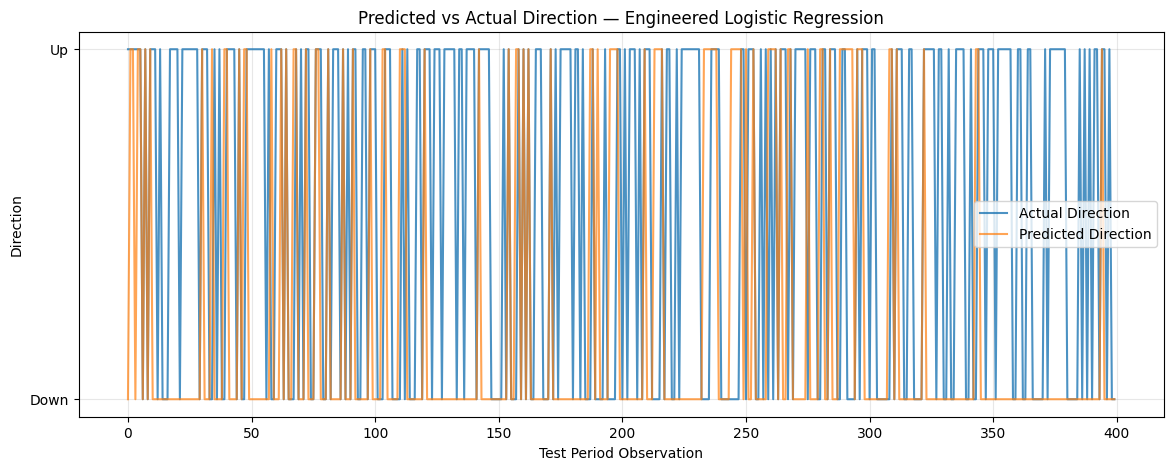

In [22]:
# Select the better engineered model based on test accuracy
if eng_lr_accuracy >= eng_rf_accuracy:
    best_predictions = eng_lr_predictions
    best_model_name = "Engineered Logistic Regression"
else:
    best_predictions = eng_rf_predictions
    best_model_name = "Engineered Random Forest"

plt.figure(figsize=(14, 5))

plt.plot(
    y_test.values,
    label="Actual Direction",
    alpha=0.8
)

plt.plot(
    best_predictions,
    label="Predicted Direction",
    alpha=0.7
)

plt.yticks([0, 1], ["Down", "Up"])
plt.xlabel("Test Period Observation")
plt.ylabel("Direction")
plt.title(f"Predicted vs Actual Direction — {best_model_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 15. Confusion Matrix

A confusion matrix shows how well the best engineered model distinguishes
between Up and Down movements.

- True Negative: Actual Down, predicted Down
- False Positive: Actual Down, predicted Up
- False Negative: Actual Up, predicted Down
- True Positive: Actual Up, predicted Up

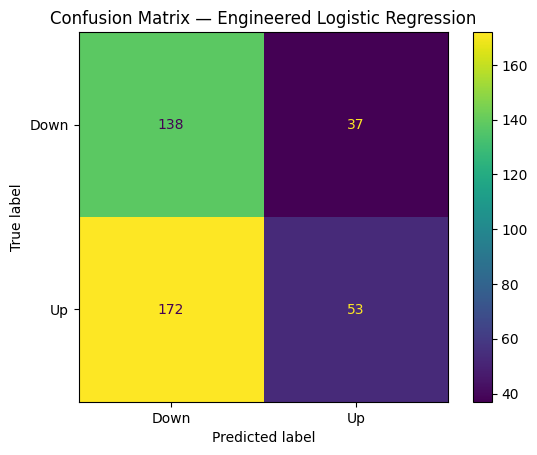

In [23]:
# Confusion matrix for the best engineered model
cm = confusion_matrix(y_test, best_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Down", "Up"]
)

disp.plot()
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

## 16. Model Accuracy Comparison

This chart provides a simple visual comparison of the two baselines and
the three machine learning approaches on the unseen test set.

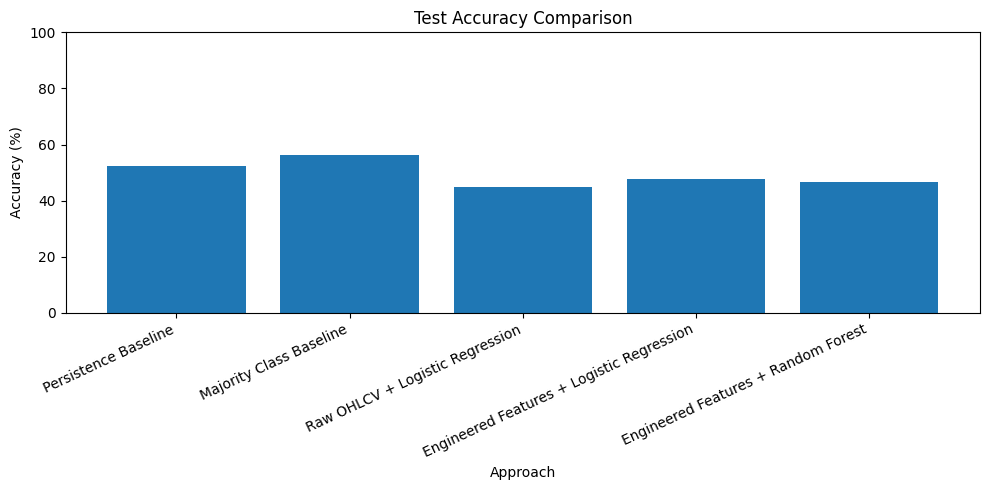

In [24]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison["Approach"],
    comparison["Test Accuracy"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Approach")
plt.title("Test Accuracy Comparison")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## 17. Detailed Evaluation of the Best Model

Accuracy alone does not show how the model performs for each direction.
We therefore examine precision, recall, and F1-score for the best
engineered-feature model.

In [26]:
print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {accuracy_score(y_test, best_predictions):.2%}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Down", "Up"]
    )
)

Best Model: Engineered Logistic Regression
Test Accuracy: 47.75%

Classification Report:
              precision    recall  f1-score   support

        Down       0.45      0.79      0.57       175
          Up       0.59      0.24      0.34       225

    accuracy                           0.48       400
   macro avg       0.52      0.51      0.45       400
weighted avg       0.53      0.48      0.44       400



## 18. Feature Importance

For the Random Forest model, feature importance shows which engineered
features contributed most to its predictions.

This is used for interpretation, not to claim that a feature causes
future price movements.

,Feature,Importance
2,Return_1,0.208146
4,Volume_Change,0.204258
0,SMA_10,0.200322
1,Momentum_5,0.194729
3,Volatility_10,0.192545


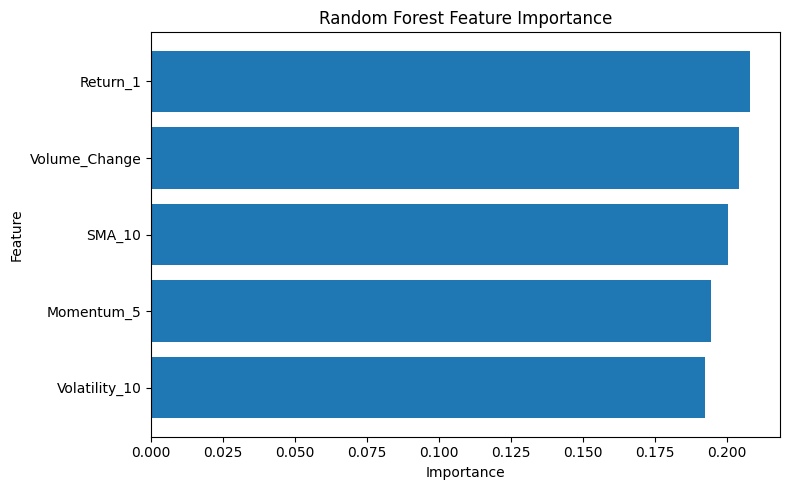

In [28]:
feature_importance = pd.DataFrame({
    "Feature": engineered_features,
    "Importance": eng_rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 19. Final Conclusion

The results show how the machine learning models compare with simple
naive baselines for next-day stock direction prediction.

The analysis focuses on whether the models provide meaningful improvement
over the baselines rather than simply maximizing accuracy.

Because stock prices are noisy and difficult to predict, performance close
to random guessing should be interpreted cautiously.

The final conclusion should be based on the actual test-set results and
forward time-series validation scores obtained above.

In [29]:
print("========== FINAL RESULTS ==========")

print(f"Persistence Baseline: {persistence_accuracy:.2%}")
print(f"Majority Class Baseline: {majority_accuracy:.2%}")
print(f"Raw OHLCV + Logistic Regression: {raw_accuracy:.2%}")
print(f"Engineered + Logistic Regression: {eng_lr_accuracy:.2%}")
print(f"Engineered + Random Forest: {eng_rf_accuracy:.2%}")

print("\n========== CROSS-VALIDATION ==========")

print(
    f"Engineered Logistic Regression CV Mean: "
    f"{np.mean(lr_cv_scores):.2%}"
)

print(
    f"Engineered Random Forest CV Mean: "
    f"{np.mean(rf_cv_scores):.2%}"
)

print("\nBest engineered model on test set:", best_model_name)

========== FINAL RESULTS ==========
Persistence Baseline: 52.25%
Majority Class Baseline: 56.25%
Raw OHLCV + Logistic Regression: 45.00%
Engineered + Logistic Regression: 47.75%
Engineered + Random Forest: 46.75%

========== CROSS-VALIDATION ==========
Engineered Logistic Regression CV Mean: 51.05%
Engineered Random Forest CV Mean: 49.02%

Best engineered model on test set: Engineered Logistic Regression
